In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utilsforecast.plotting import plot_series

In [2]:
pd.plotting.register_matplotlib_converters()
plt.rc("figure", figsize=(10, 8))
plt.rc("font", size=10)

In [3]:
data_url = 'https://raw.githubusercontent.com/panambY/Hourly_Energy_Consumption/master/data/PJM_Load_hourly.csv'
df = pd.read_csv(data_url, parse_dates=['Datetime'])
df.columns = ['ds', 'y']
df.insert(0, 'unique_id', 'PJM_Load_hourly')
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)
print(f'Shape of the data {df.shape}')
df.tail()

# 1) Duplicates
dups = df[df.duplicated(['unique_id', 'ds'], keep=False)]
print("Duplicate timestamp rows:", len(dups))
display(dups.head(10))

# 2) Missing hours (compare expected hourly grid vs actual)
g = df[df['unique_id'] == 'PJM_Load_hourly'].copy()
full = pd.date_range(g['ds'].min(), g['ds'].max(), freq='h')

missing = full.difference(g['ds'])
print("Missing hours:", len(missing))
print("First few missing:", list(missing[:10]))

Shape of the data (32896, 3)
Duplicate timestamp rows: 0


,unique_id,ds,y


Missing hours: 8
First few missing: [Timestamp('1998-04-05 03:00:00'), Timestamp('1998-10-25 02:00:00'), Timestamp('1999-04-04 03:00:00'), Timestamp('1999-10-31 02:00:00'), Timestamp('2000-04-02 03:00:00'), Timestamp('2000-10-29 02:00:00'), Timestamp('2001-04-01 03:00:00'), Timestamp('2001-10-28 02:00:00')]


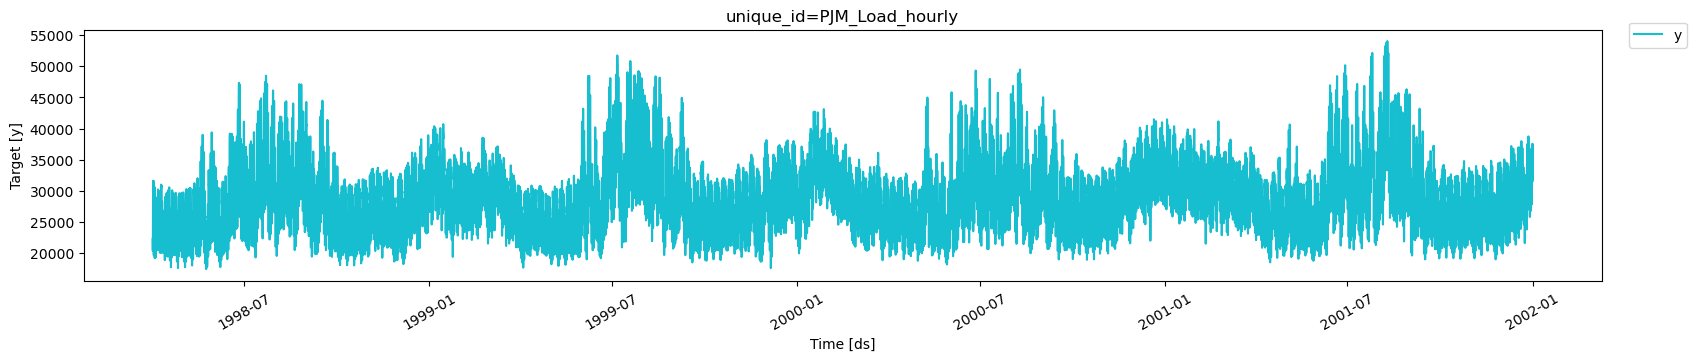

In [4]:
fig = plot_series(df)
fig

In [5]:
# ---- clean df first ----
df = (
    df.groupby(['unique_id', 'ds'], as_index=False)
      .agg({'y': 'mean'})
)

def make_hourly(g):
    uid = g.name                     # <-- the group key is here
    g = g.sort_values('ds').set_index('ds')[['y']]

    idx = pd.date_range(g.index.min(), g.index.max(), freq='h')
    g = g.reindex(idx)

    g['y'] = g['y'].interpolate(limit_direction='both').ffill().bfill()
    g['unique_id'] = uid
    return g.reset_index().rename(columns={'index': 'ds'})

df = (
    df.groupby('unique_id', group_keys=False)
      .apply(make_hourly)
      .reset_index(drop=True)
)

df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

# ---- NOW split after cleaning ----
threshold_time = df['ds'].max() - pd.Timedelta(hours=24)
df_train = df[df['ds'] <= threshold_time].copy()
df_last_24_hours = df[df['ds'] > threshold_time].copy()



C:\Users\mosta\AppData\Local\Temp\ipykernel_42832\605087558.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(make_hourly)


In [6]:
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences

In [7]:
import os
os.makedirs('figs', exist_ok=True)

def plot_differences(df, differences,fname):
    prep = [df]
    # Plot individual Differences
    for d in differences:
        fcst = MLForecast(
        models=[],  # we're not interested in modeling yet
        freq='h',  # our series have hourly frequency
        target_transforms=[Differences([d])],
        )
        df_ = fcst.preprocess(df)
        df_['unique_id'] = df_['unique_id'] + f'_{d}'
        prep.append(df_)

    # Plot combined Differences
    fcst = MLForecast(
    models=[],  # we're not interested in modeling yet
    freq='h',  # our series have hourly frequency
    target_transforms=[Differences([24, 24*7])],
    )
    df_ = fcst.preprocess(df)
    df_['unique_id'] = df_['unique_id'] + f'_all_diff'
    prep.append(df_)
    prep = pd.concat(prep, ignore_index=True)
    #return prep
    n_series = len(prep['unique_id'].unique())
    fig, ax = plt.subplots(nrows=n_series, figsize=(7 * n_series, 10*n_series), squeeze=False)
    for title, axi in zip(prep['unique_id'].unique(), ax.flat):
        df_ = prep[prep['unique_id'] == title]
        df_.set_index('ds')['y'].plot(title=title, ax=axi)
    fig.savefig(f'figs/{fname}', bbox_inches='tight')
    plt.show()
    plt.close()

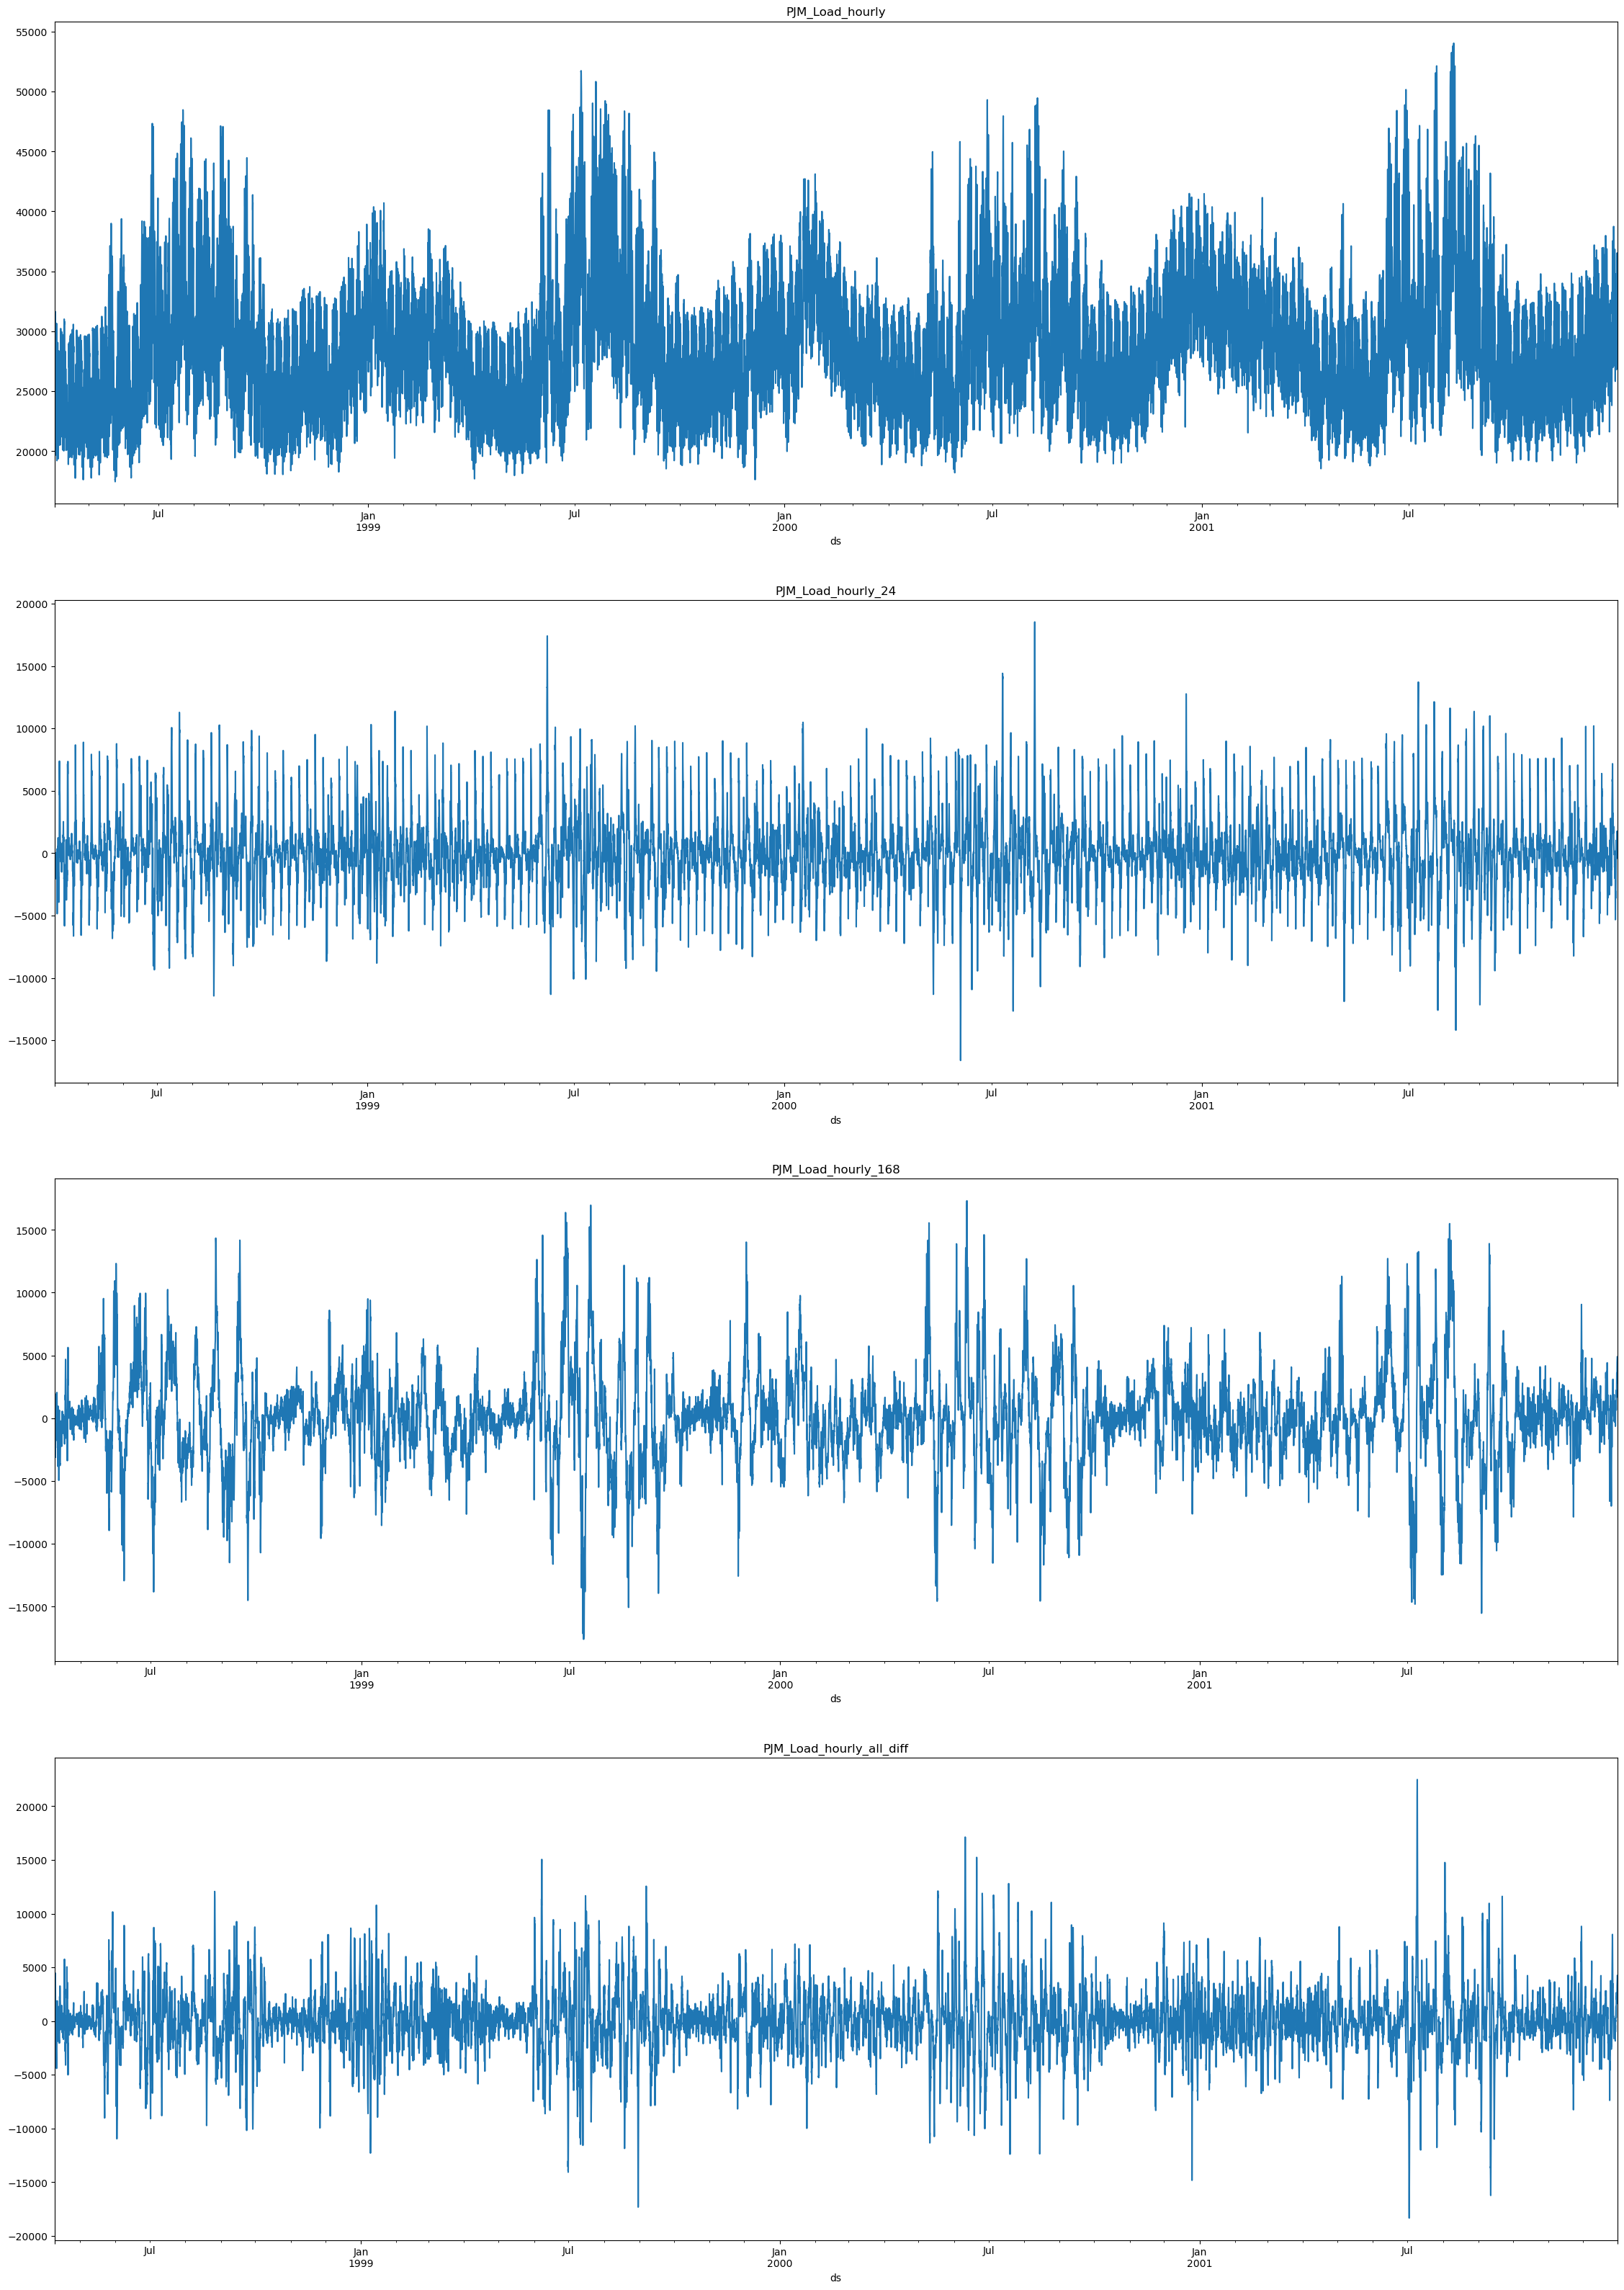

In [8]:
plot_differences(df=df_train, differences=[24, 24*7], fname='load_forecasting__differences.png')

In [9]:
fcst = MLForecast(
    models=[],  # we're not interested in modeling yet
    freq='h',  # our series have hourly frequency
    target_transforms=[Differences([24, 24*7])],
)
prep = fcst.preprocess(df_train)
prep

,ds,y,unique_id
192,1998-04-09 01:00:00,874.0,PJM_Load_hourly
193,1998-04-09 02:00:00,805.0,PJM_Load_hourly
194,1998-04-09 03:00:00,825.0,PJM_Load_hourly
195,1998-04-09 04:00:00,657.0,PJM_Load_hourly
196,1998-04-09 05:00:00,875.0,PJM_Load_hourly
...,...,...,...
32875,2001-12-30 20:00:00,3417.0,PJM_Load_hourly
32876,2001-12-30 21:00:00,3596.0,PJM_Load_hourly
32877,2001-12-30 22:00:00,3501.0,PJM_Load_hourly
32878,2001-12-30 23:00:00,3939.0,PJM_Load_hourly


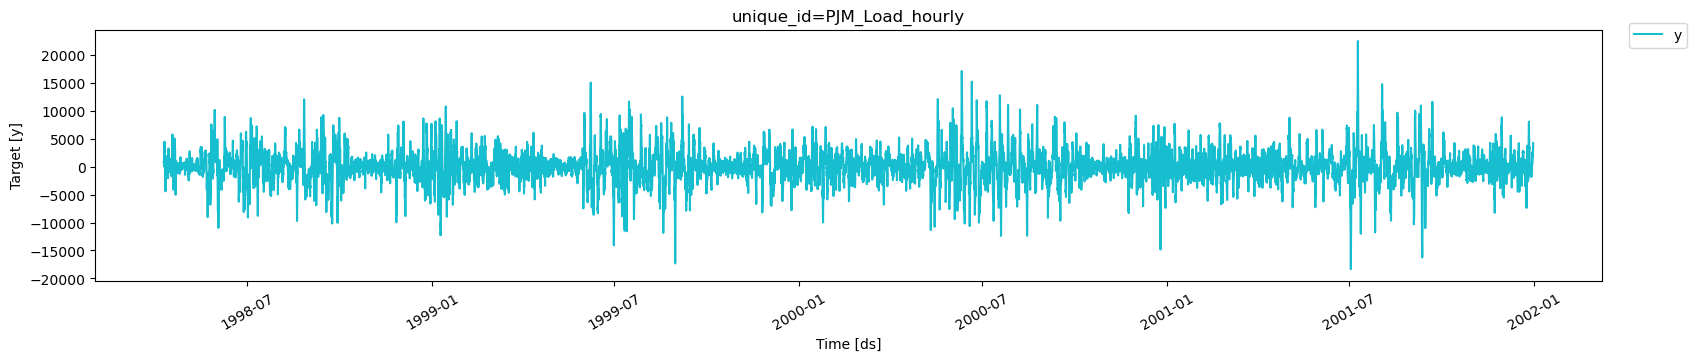

In [10]:
fig = plot_series(prep)
fig

In [11]:
import lightgbm as lgb
from sklearn.base import BaseEstimator
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor

from mlforecast.lag_transforms import ExpandingMean, RollingMean
from mlforecast.target_transforms import Differences

In [12]:
class Naive(BaseEstimator):
    def fit(self, X, y):
        return self

    def predict(self, X):
        return X['lag1']

In [13]:
# Model dictionary
models ={
        'naive': Naive(),
        'lgbm': lgb.LGBMRegressor(verbosity=-1),
        'lasso': Lasso(),
        'lin_reg': LinearRegression(),
        'ridge': Ridge(),
        'knn': KNeighborsRegressor(),
        'mlp': MLPRegressor(),
        'rf': RandomForestRegressor()
    }

In [14]:
lags=[1,12,24]

In [15]:
mlf = MLForecast(
    models = models,
    freq='h',  # our series have hourly frequency
    target_transforms=[Differences([24, 24*7])],
    lags=[1,12,24], # Lags to be used as features
    lag_transforms={
        1: [ExpandingMean()],
        24: [RollingMean(window_size=48)],
    },
    date_features=['month', 'hour', 'dayofweek']
)

In [16]:
crossvalidation_df = mlf.cross_validation(
    df=df_train,
    h=24,
    n_windows=4,
    refit=False,
)
crossvalidation_df.head()

,unique_id,ds,cutoff,y,naive,lgbm,lasso,lin_reg,ridge,knn,mlp,rf
0,PJM_Load_hourly,2001-12-27 01:00:00,2001-12-27,28332.0,28837.0,28497.334712,28704.680891,28704.363400,28704.363407,28479.0,28755.991330,28173.21
1,PJM_Load_hourly,2001-12-27 02:00:00,2001-12-27,27329.0,27969.0,27463.740633,27696.369854,27695.723641,27695.723656,27521.6,27790.040778,27148.22
2,PJM_Load_hourly,2001-12-27 03:00:00,2001-12-27,26986.0,27435.0,26569.210275,26995.847941,26994.864328,26994.864350,26451.6,27144.098090,26369.40
3,PJM_Load_hourly,2001-12-27 04:00:00,2001-12-27,27009.0,27401.0,26316.377229,26794.544296,26793.211702,26793.211731,26388.4,26994.636336,26317.71
4,PJM_Load_hourly,2001-12-27 05:00:00,2001-12-27,27555.0,28169.0,26901.287988,27375.665835,27373.974238,27373.974274,26779.6,27635.695573,27042.26


In [17]:
def plot_cv(df, df_cv, uid, fname, last_n=24 * 14, models={}):
    cutoffs = df_cv.query('unique_id == @uid')['cutoff'].unique()
    fig, ax = plt.subplots(nrows=len(cutoffs), ncols=1, figsize=(14, 14), gridspec_kw=dict(hspace=0.8))
    for cutoff, axi in zip(cutoffs, ax.flat):
        max_date = df_cv.query('unique_id == @uid & cutoff == @cutoff')['ds'].max()
        df[df['ds'] < max_date].query('unique_id == @uid').tail(last_n).set_index('ds').plot(ax=axi, title=uid, y='y')
        for m in models.keys():
            df_cv.query('unique_id == @uid & cutoff == @cutoff').set_index('ds').plot(ax=axi, title=uid, y=m)
    fig.savefig(f'figs/{fname}', bbox_inches='tight')
    plt.show()
    plt.close()

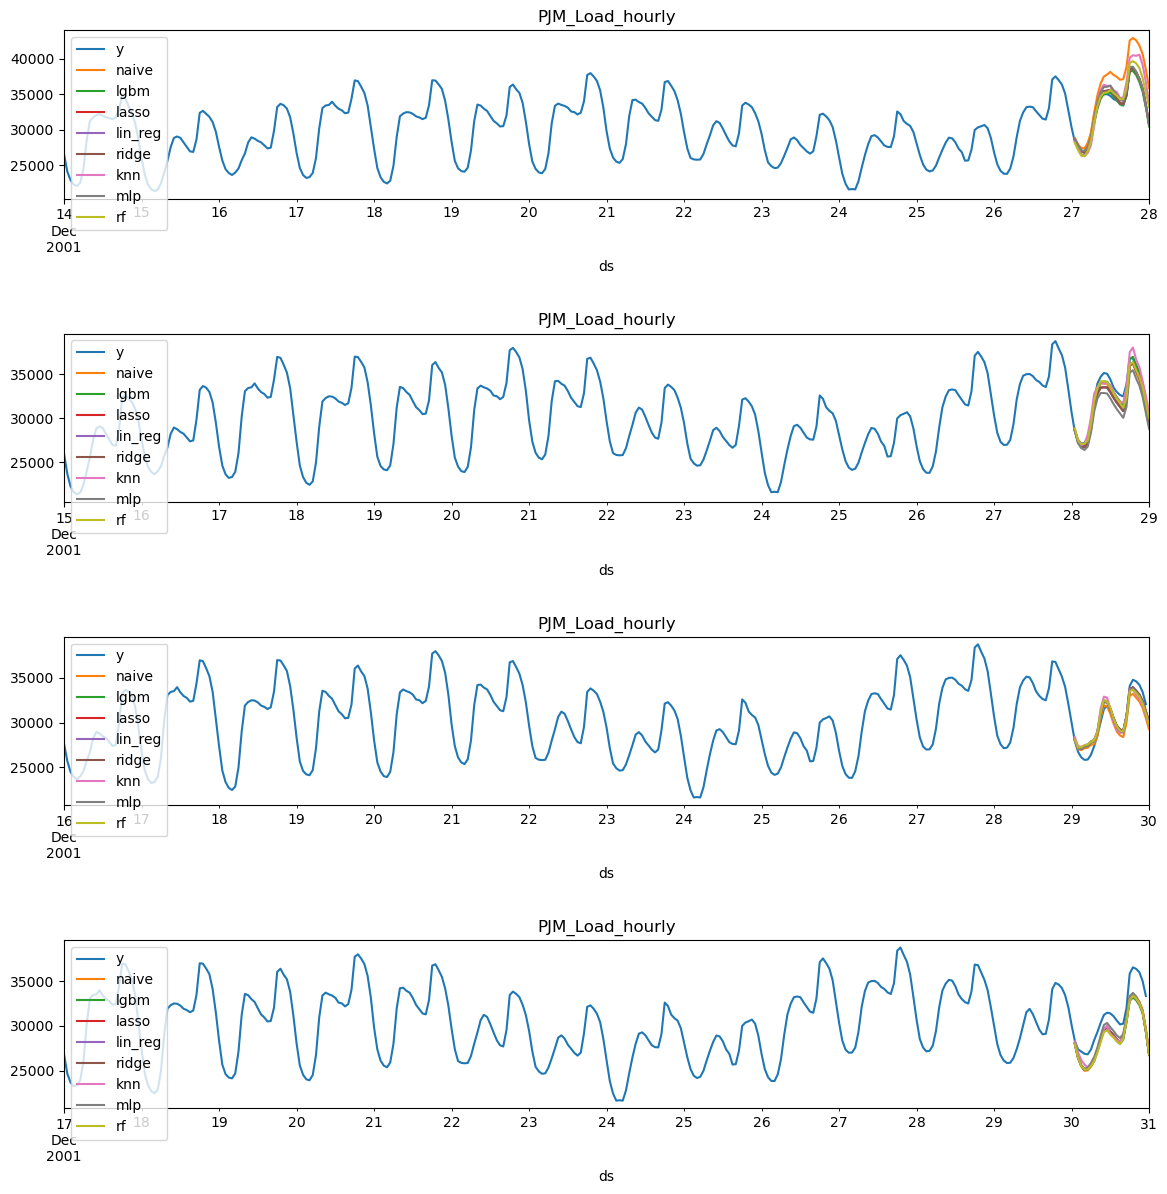

In [18]:
plot_cv(df_train, crossvalidation_df, 'PJM_Load_hourly', 'load_forecasting__predictions.png', models=models)

In [19]:
from utilsforecast.losses import mae, mape, rmse, smape
from utilsforecast.evaluation import evaluate

In [20]:
# Metrics to be used for evaluation
metrics = [
    mae,
    rmse,
    mape,
    smape
]

In [21]:
# Function to evaluate the crossvalidation
def evaluate_crossvalidation(crossvalidation_df, metrics, models):
    evaluations = []
    for c in crossvalidation_df['cutoff'].unique():
        df_cv = crossvalidation_df.query('cutoff == @c')
        evaluation = evaluate(
            df = df_cv,
            metrics=metrics,
            models=list(models.keys())
            )
        evaluations.append(evaluation)
    evaluations = pd.concat(evaluations, ignore_index=True).drop(columns='unique_id')
    evaluations = evaluations.groupby('metric').mean()
    return evaluations.style.background_gradient(cmap='RdYlGn_r', axis=1)

In [22]:
evaluate_crossvalidation(crossvalidation_df, metrics, models)

,cutoff,naive,lgbm,lasso,lin_reg,ridge,knn,mlp,rf
metric,,,,,,,,,
mae,2001-12-28 12:00:00,1631.395833,953.739047,1004.922597,1007.588870,1007.588828,1258.225000,1130.290019,1121.976823
mape,2001-12-28 12:00:00,0.049759,0.030389,0.031795,0.031876,0.031876,0.039068,0.035277,0.035316
rmse,2001-12-28 12:00:00,1871.398919,1103.659832,1149.711112,1152.758707,1152.758661,1454.024648,1300.101518,1284.336616
smape,2001-12-28 12:00:00,0.024786,0.015590,0.016286,0.016330,0.016330,0.019715,0.018051,0.018012


In [23]:
from mlforecast.utils import PredictionIntervals

In [24]:
models_evaluation ={
        'lgbm': lgb.LGBMRegressor(verbosity=-1),
        'lasso': Lasso(),
    }

mlf_evaluation = MLForecast(
    models = models_evaluation,
    freq='h',  # our series have hourly frequency
    target_transforms=[Differences([24, 24*7])],
    lags=[1,12,24],
    lag_transforms={
        1: [ExpandingMean()],
        24: [RollingMean(window_size=48)],
    },
    date_features=['month', 'hour', 'dayofweek']
)

In [25]:
mlf_evaluation.fit(
    df = df_train,
    prediction_intervals=PredictionIntervals(n_windows=4, h=24)
)

MLForecast(models=[lgbm, lasso], freq=h, lag_features=['lag1', 'lag12', 'lag24', 'expanding_mean_lag1', 'rolling_mean_lag24_window_size48'], date_features=['month', 'hour', 'dayofweek'], num_threads=1)

In [27]:
fcst = MLForecast(
    models=models,   # your model dict
    freq='H',
    lags=[1, 12, 24],
    lag_transforms={
        1: [ExpandingMean()],
        24: [RollingMean(window_size=48)]
    },
    date_features=['month', 'hour', 'dayofweek'],
    num_threads=1
)

In [28]:
levels = [90, 95] # Levels for prediction intervals
forecasts = mlf_evaluation.predict(24, level=levels)
forecasts.head()

,unique_id,ds,lgbm,lasso,lgbm-lo-95,lgbm-lo-90,lgbm-hi-90,lgbm-hi-95,lasso-lo-95,lasso-lo-90,lasso-hi-90,lasso-hi-95
0,PJM_Load_hourly,2001-12-31 01:00:00,28904.255313,29126.179231,28592.538921,28623.020942,29185.489684,29215.971706,28763.661572,28773.824804,29478.533658,29488.696890
1,PJM_Load_hourly,2001-12-31 02:00:00,27893.689738,28369.398316,27008.445673,27095.400021,28691.979455,28778.933804,27532.861059,27623.058187,29115.738446,29205.935574
2,PJM_Load_hourly,2001-12-31 03:00:00,27089.487780,27718.092682,25568.798824,25665.737844,28513.237716,28610.176736,26243.277777,26343.919848,29092.265516,29192.907587
3,PJM_Load_hourly,2001-12-31 04:00:00,27053.648843,27669.315850,25278.590810,25314.914172,28792.383514,28828.706876,25919.422405,25967.445804,29371.185896,29419.209295
4,PJM_Load_hourly,2001-12-31 05:00:00,26823.494991,27403.441670,25144.273180,25147.461501,28499.528480,28502.716802,25761.760447,25771.910779,29034.972560,29045.122893


In [29]:
test = df_last_24_hours.merge(forecasts, how='left', on=['unique_id', 'ds'])
test.head()

,ds,y,unique_id,lgbm,lasso,lgbm-lo-95,lgbm-lo-90,lgbm-hi-90,lgbm-hi-95,lasso-lo-95,lasso-lo-90,lasso-hi-90,lasso-hi-95
0,2001-12-31 01:00:00,29001.0,PJM_Load_hourly,28904.255313,29126.179231,28592.538921,28623.020942,29185.489684,29215.971706,28763.661572,28773.824804,29478.533658,29488.696890
1,2001-12-31 02:00:00,28138.0,PJM_Load_hourly,27893.689738,28369.398316,27008.445673,27095.400021,28691.979455,28778.933804,27532.861059,27623.058187,29115.738446,29205.935574
2,2001-12-31 03:00:00,27830.0,PJM_Load_hourly,27089.487780,27718.092682,25568.798824,25665.737844,28513.237716,28610.176736,26243.277777,26343.919848,29092.265516,29192.907587
3,2001-12-31 04:00:00,27874.0,PJM_Load_hourly,27053.648843,27669.315850,25278.590810,25314.914172,28792.383514,28828.706876,25919.422405,25967.445804,29371.185896,29419.209295
4,2001-12-31 05:00:00,28427.0,PJM_Load_hourly,26823.494991,27403.441670,25144.273180,25147.461501,28499.528480,28502.716802,25761.760447,25771.910779,29034.972560,29045.122893


In [30]:
evaluate(
    df = test,
    metrics=metrics,
    models=list(models_evaluation.keys())
)

,unique_id,metric,lgbm,lasso
0,PJM_Load_hourly,mae,936.223615,904.651701
1,PJM_Load_hourly,rmse,1195.371329,1168.048115
2,PJM_Load_hourly,mape,0.029088,0.027818
3,PJM_Load_hourly,smape,0.014732,0.013871


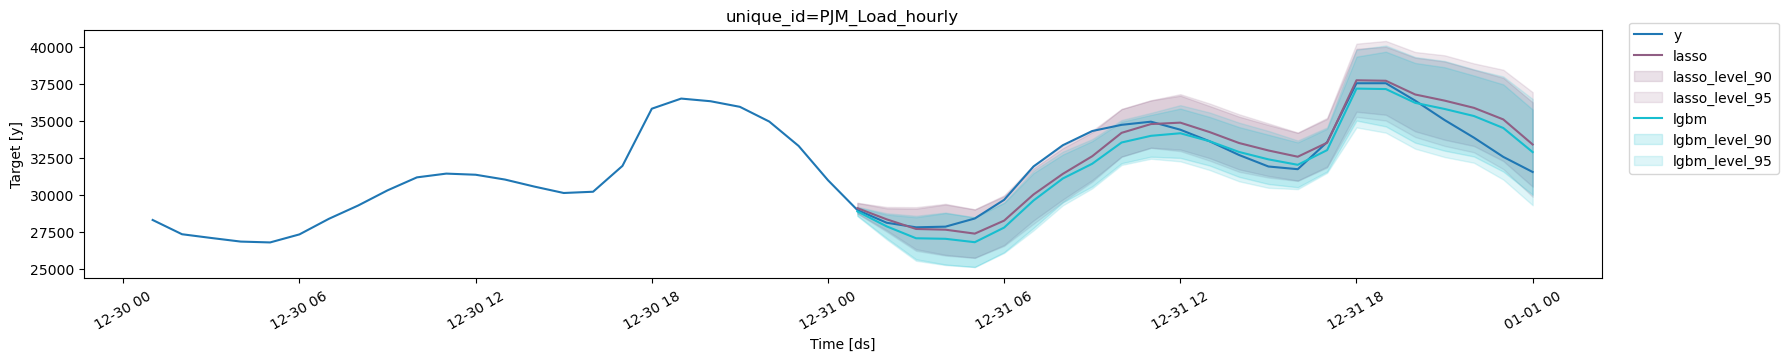

In [32]:
fig = plot_series(
    df_train,
    test,
    models=['lasso', 'lgbm'],
    plot_random=False,
    level=levels,
    max_insample_length=24
)
fig

In [33]:
from prophet import Prophet
from time import time

In [34]:
# create prophet model
prophet = Prophet(interval_width=0.9)
init = time()
prophet.fit(df_train)
# produce forecasts
future = prophet.make_future_dataframe(periods=len(df_last_24_hours), freq='H', include_history=False)
forecast_prophet = prophet.predict(future)
end = time()
# data wrangling
forecast_prophet = forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_prophet.columns = ['ds', 'Prophet', 'Prophet-lo-90', 'Prophet-hi-90']
forecast_prophet.insert(0, 'unique_id', 'PJM_Load_hourly')
forecast_prophet.head()

20:32:28 - cmdstanpy - INFO - Chain [1] start processing
20:33:01 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\mosta\anaconda3\envs\enel619\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


,unique_id,ds,Prophet,Prophet-lo-90,Prophet-hi-90
0,PJM_Load_hourly,2001-12-31 01:00:00,25361.983029,20737.936245,30254.026265
1,PJM_Load_hourly,2001-12-31 02:00:00,24070.969736,19094.250970,29118.133268
2,PJM_Load_hourly,2001-12-31 03:00:00,23394.874186,18465.736806,28345.124707
3,PJM_Load_hourly,2001-12-31 04:00:00,23399.806366,18781.920800,28249.057233
4,PJM_Load_hourly,2001-12-31 05:00:00,24170.818650,19567.906380,28922.320480


In [35]:
time_prophet = (end - init)
print(f'Prophet Time: {time_prophet:.2f} seconds')

Prophet Time: 41.50 seconds


In [37]:
models_comparison ={
    'lgbm': lgb.LGBMRegressor(verbosity=-1)
}

mlf_comparison = MLForecast(
    models = models_comparison,
    freq='h',  # our series have hourly frequency
    target_transforms=[Differences([24, 24*7])],
    lags=[1,12,24],
    lag_transforms={
        1: [ExpandingMean()],
        24: [RollingMean(window_size=48)],
    },
    date_features=['month', 'hour', 'dayofweek']
)

init = time()
mlf_comparison.fit(
    df = df_train,
    prediction_intervals=PredictionIntervals(n_windows=4, h=24)
)

levels = [90]
forecasts_comparison = mlf_comparison.predict(24, level=levels)
end = time()
forecasts_comparison.head()

,unique_id,ds,lgbm,lgbm-lo-90,lgbm-hi-90
0,PJM_Load_hourly,2001-12-31 01:00:00,28904.255313,28623.020942,29185.489684
1,PJM_Load_hourly,2001-12-31 02:00:00,27893.689738,27095.400021,28691.979455
2,PJM_Load_hourly,2001-12-31 03:00:00,27089.487780,25665.737844,28513.237716
3,PJM_Load_hourly,2001-12-31 04:00:00,27053.648843,25314.914172,28792.383514
4,PJM_Load_hourly,2001-12-31 05:00:00,26823.494991,25147.461501,28499.528480


In [38]:
time_lgbm = (end - init)
print(f'LGBM Time: {time_lgbm:.2f} seconds')

LGBM Time: 4.41 seconds


In [39]:
metrics_comparison = df_last_24_hours.merge(forecasts_comparison, how='left', on=['unique_id', 'ds']).merge(
    forecast_prophet, how='left', on=['unique_id', 'ds'])
metrics_comparison = evaluate(
            df = metrics_comparison,
            metrics=metrics,
            models=['Prophet', 'lgbm']
            )
metrics_comparison.reset_index(drop=True).style.background_gradient(cmap='RdYlGn_r', axis=1)

,unique_id,metric,Prophet,lgbm
0,PJM_Load_hourly,mae,2255.726612,936.223615
1,PJM_Load_hourly,rmse,2687.710980,1195.371329
2,PJM_Load_hourly,mape,0.072876,0.029088
3,PJM_Load_hourly,smape,0.038112,0.014732


In [40]:
metrics_comparison['improvement'] = metrics_comparison['Prophet'] /  metrics_comparison['lgbm']
metrics_comparison['improvement'] = metrics_comparison['improvement'].apply(lambda x: f'{x:.2f}')
metrics_comparison.set_index('metric')[['improvement']]

,improvement
metric,
mae,2.41
rmse,2.25
mape,2.51
smape,2.59


In [41]:
print(f'lgbm with MLForecast has a speedup of {time_prophet/time_lgbm:.2f} compared with prophet')

lgbm with MLForecast has a speedup of 9.41 compared with prophet
